## 0. Setup

Load the cleaned parquet, derive the 7 engineered features, persist the engineered dataset, and import the importance + SHAP helpers.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Repo-root substitution (set by the notebook builder).
REPO_ROOT = Path(r"F:\Git Repo\DA Lab Project")
PARQUET_CLEAN = REPO_ROOT / "data" / "processed" / "train_clean.parquet"
PARQUET_ENG = REPO_ROOT / "data" / "processed" / "train_engineered.parquet"
PARQUET_TOP30 = REPO_ROOT / "data" / "processed" / "train_top30.parquet"
FIG_DIR = REPO_ROOT / "reports" / "figures"
IMPORTANCE_MD = REPO_ROOT / "reports" / "feature_importance.md"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Phase-5 palette for charts.
PALETTE = {
    "bg":      "#0A1428",
    "panel":   "#10203D",
    "mint":    "#00D9B5",
    "blue":    "#3B82F6",
    "red":     "#F87171",
    "white":   "#FFFFFF",
    "body":    "#CBD5E1",
    "muted":   "#94A3B8",
}
mpl.rcParams.update({
    "figure.facecolor":  PALETTE["bg"],
    "axes.facecolor":    PALETTE["panel"],
    "axes.edgecolor":    PALETTE["muted"],
    "axes.labelcolor":   PALETTE["body"],
    "axes.titlecolor":   PALETTE["white"],
    "xtick.color":       PALETTE["body"],
    "ytick.color":       PALETTE["body"],
    "text.color":        PALETTE["body"],
    "grid.color":        PALETTE["panel"],
    "grid.alpha":        0.5,
    "savefig.facecolor": PALETTE["bg"],
    "savefig.dpi":       130,
})

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"Cleaned parquet exists: {PARQUET_CLEAN.exists()}")

REPO_ROOT = F:\Git Repo\DA Lab Project
Cleaned parquet exists: True


In [2]:
# Load cleaned data and engineer features.
df = pd.read_parquet(PARQUET_CLEAN)
print(f"Loaded cleaned parquet: {df.shape}")

from src.features.engineer import engineer_features, ENGINEERED_COLUMNS
df_eng = engineer_features(df)
print(f"Engineered shape: {df_eng.shape}")
print(f"Engineered columns ({len(ENGINEERED_COLUMNS)}):")
for c in ENGINEERED_COLUMNS:
    n_nan = int(df_eng[c].isna().sum())
    print(f"  {c:25s} NaN={n_nan:,} ({n_nan/len(df_eng):.1%})")

# Persist the engineered dataset (all rows, all slices, all columns).
df_eng.to_parquet(PARQUET_ENG, index=False)
print(f"Wrote {PARQUET_ENG}")

Loaded cleaned parquet: (307511, 144)


Engineered shape: (307511, 151)
Engineered columns (7):
  AGE_YEARS                 NaN=0 (0.0%)
  EMPLOYED_YEARS            NaN=0 (0.0%)
  CREDIT_INCOME_RATIO       NaN=187,136 (60.9%)
  ANNUITY_INCOME_RATIO      NaN=187,136 (60.9%)
  CREDIT_GOODS_RATIO        NaN=185,441 (60.3%)
  INCOME_PER_FAM_MEMBER     NaN=226,206 (73.6%)
  EXT_SOURCE_MEAN           NaN=0 (0.0%)


Wrote F:\Git Repo\DA Lab Project\data\processed\train_engineered.parquet


## 1. Engineered-Feature Sanity Check

Descriptive statistics for each engineered column, plus a 4-panel histogram.

In [3]:
feat_stats = df_eng[list(ENGINEERED_COLUMNS)].describe().T
print(feat_stats[["mean", "std", "min", "50%", "max"]].round(3).to_string())

                        mean     std       min    50%       max
AGE_YEARS              0.000   0.003    -0.005 -0.000     0.006
EMPLOYED_YEARS        -0.000   0.003    -0.003 -0.001     0.020
CREDIT_INCOME_RATIO    2.554  34.948 -1602.942  0.792  6327.883
ANNUITY_INCOME_RATIO   2.715  31.313 -2482.095  1.244  5363.400
CREDIT_GOODS_RATIO     0.812   8.081  -305.897  1.035   112.627
INCOME_PER_FAM_MEMBER  0.020   1.641    -0.556 -0.045   456.893
EXT_SOURCE_MEAN        0.001   0.639    -2.943  0.055     2.099


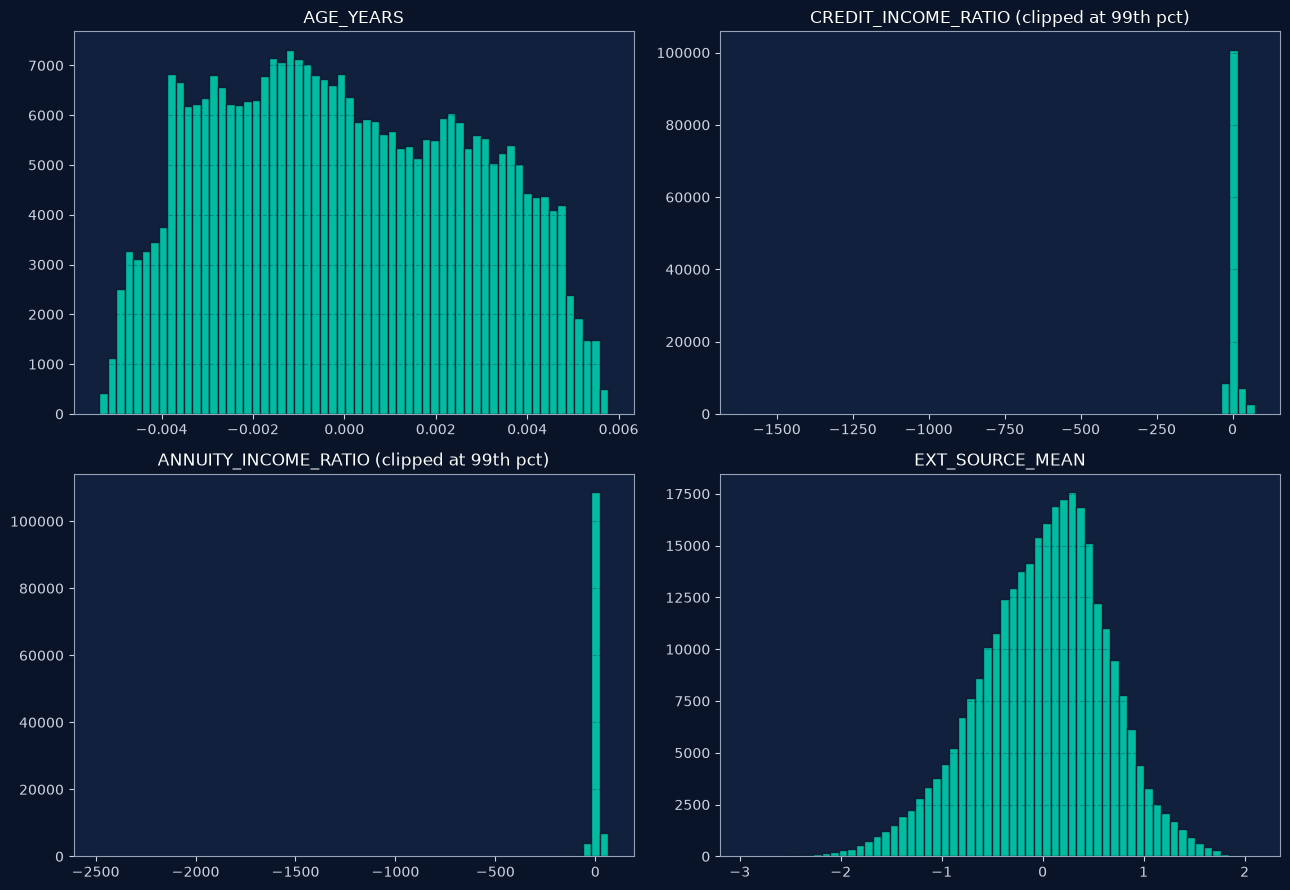

Saved 13_engineered_features.png


In [4]:
# 4-panel histogram of the most informative engineered features.
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, ["AGE_YEARS", "CREDIT_INCOME_RATIO",
                                "ANNUITY_INCOME_RATIO", "EXT_SOURCE_MEAN"]):
    vals = df_eng[col].dropna()
    if col == "CREDIT_INCOME_RATIO" or col == "ANNUITY_INCOME_RATIO":
        ax.hist(vals.clip(upper=vals.quantile(0.99)), bins=60,
                color=PALETTE["mint"], edgecolor=PALETTE["bg"], alpha=0.85)
        ax.set_title(f"{col} (clipped at 99th pct)")
    else:
        ax.hist(vals, bins=60, color=PALETTE["mint"],
                edgecolor=PALETTE["bg"], alpha=0.85)
        ax.set_title(col)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "13_engineered_features.png")
plt.show()
print("Saved 13_engineered_features.png")

## 2. XGBoost + Random Forest Importance

Train both models on the **train slice** (215,257 rows × 148 features) to extract importances. No CV — this is purely to rank features; Phase 4 does the real model training.

In [5]:
from src.features.select import train_xgb_and_rf_importances

df_train = df_eng[df_eng["SPLIT"] == "train"].reset_index(drop=True)
feature_cols = [c for c in df_train.columns if c not in ("SK_ID_CURR", "TARGET", "SPLIT")]
X_train = df_train[feature_cols]
y_train = df_train["TARGET"]

print(f"Training rows: {len(X_train):,}, features: {len(feature_cols)}")
print(f"Positive rate: {y_train.mean():.4%}")

t0 = time.time()
imp = train_xgb_and_rf_importances(X_train, y_train, random_state=42)
print(f"Importance extraction took {time.time() - t0:.1f}s")
print(f"Top 15 features by mean rank:")
print(imp.head(15)[["feature", "xgb_importance", "rf_importance",
                    "xgb_rank", "rf_rank", "mean_rank"]].to_string(index=False))

Training rows: 215,257, features: 148
Positive rate: 8.0727%


Importance extraction took 14.2s
Top 15 features by mean rank:
                                          feature  xgb_importance  rf_importance  xgb_rank  rf_rank  mean_rank
                                  EXT_SOURCE_MEAN        0.068476       0.233497         1        1        1.0
                                   EMPLOYED_YEARS        0.017394       0.032417         4        6        5.0
                                     EXT_SOURCE_1        0.011190       0.041256        12        4        8.0
             NAME_EDUCATION_TYPE_Higher education        0.028037       0.015494         2       15        8.5
                                    CODE_GENDER_M        0.018841       0.011118         3       17       10.0
                                        AGE_YEARS        0.010946       0.022362        14        8       11.0
                                  AMT_GOODS_PRICE        0.010480       0.018154        15        9       12.0
NAME_EDUCATION_TYPE_Secondary / secondary special

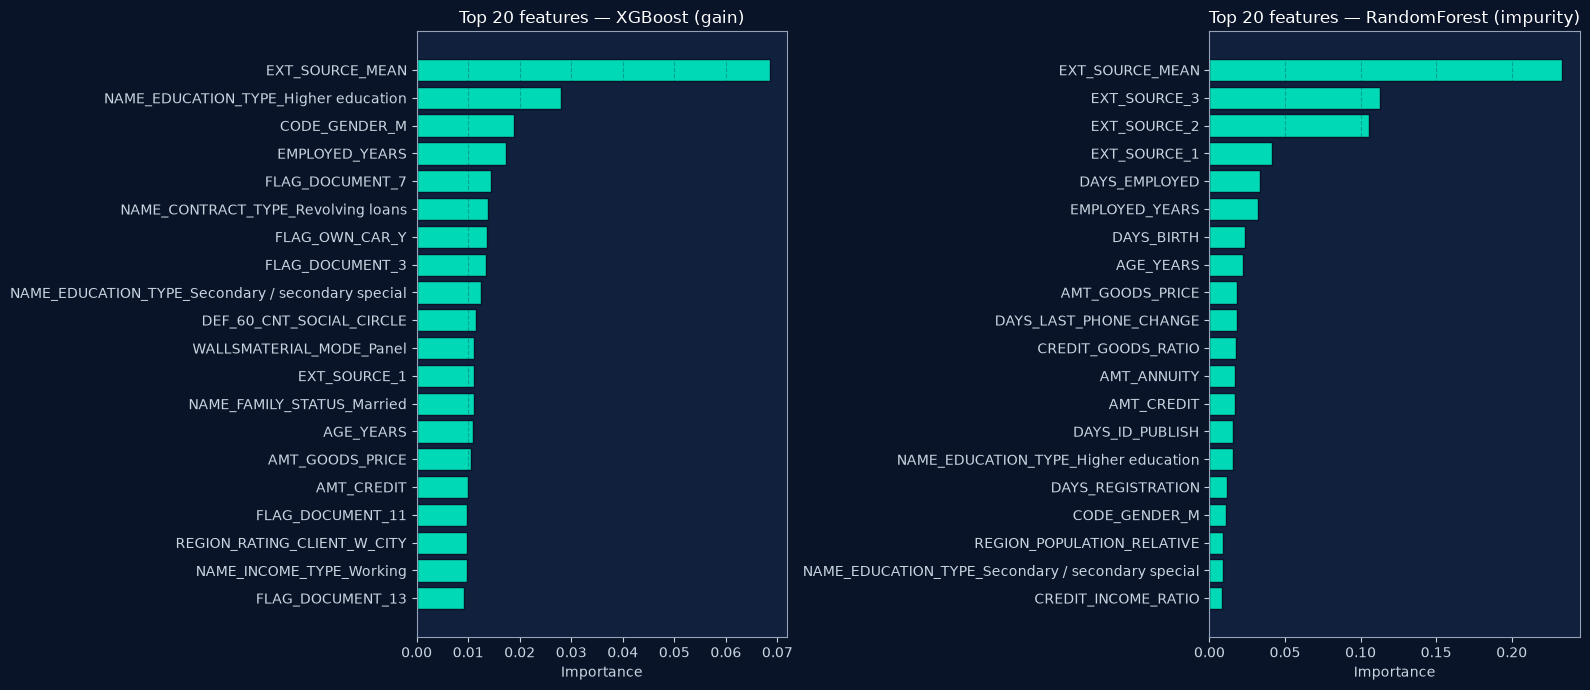

Saved 14_importance_rf_xgb.png


In [6]:
# 2-panel chart: top-20 by XGB and by RF.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, col, label in [
    (axes[0], "xgb_importance", "XGBoost (gain)"),
    (axes[1], "rf_importance", "RandomForest (impurity)"),
]:
    top = imp.nlargest(20, col).sort_values(col, ascending=True)
    ax.barh(top["feature"], top[col], color=PALETTE["mint"], edgecolor=PALETTE["bg"])
    ax.set_title(f"Top 20 features — {label}")
    ax.set_xlabel("Importance")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "14_importance_rf_xgb.png")
plt.show()
print("Saved 14_importance_rf_xgb.png")

## 3. SHAP on XGBoost

TreeSHAP is exact on boosted trees; 5,000 rows × 300 trees is enough for stable per-feature mean |SHAP|.

In [7]:
import shap
from src.features.select import shap_values_xgb

t0 = time.time()
sv, fn = shap_values_xgb(X_train, y_train, sample_size=5_000, random_state=42)
print(f"TreeSHAP took {time.time() - t0:.1f}s, shape {sv.shape}")
print(f"Top 15 features by mean |SHAP|:")
shap_mean_abs = np.abs(sv).mean(axis=0)
shap_top = (pd.DataFrame({"feature": fn, "shap_mean_abs": shap_mean_abs})
            .sort_values("shap_mean_abs", ascending=False).head(15))
print(shap_top.to_string(index=False))

TreeSHAP took 1.1s, shape (5000, 148)
Top 15 features by mean |SHAP|:
                   feature  shap_mean_abs
           EXT_SOURCE_MEAN       0.662050
              EXT_SOURCE_3       0.336285
           DAYS_ID_PUBLISH       0.287840
              EXT_SOURCE_2       0.257392
               AMT_ANNUITY       0.238826
              EXT_SOURCE_1       0.231963
         DAYS_REGISTRATION       0.219637
                DAYS_BIRTH       0.217695
REGION_POPULATION_RELATIVE       0.212830
                AMT_CREDIT       0.204287
          AMT_INCOME_TOTAL       0.203824
         ORGANIZATION_TYPE       0.196461
             CODE_GENDER_M       0.177690
        CREDIT_GOODS_RATIO       0.175769
             DAYS_EMPLOYED       0.174389


In [8]:
# SHAP summary (beeswarm) for the top-15 features.
shap_top15 = shap_top["feature"].tolist()
idx = [fn.index(f) for f in shap_top15]
shap.summary_plot(
    sv[:, idx],
    features=X_train.sample(5_000, random_state=42).iloc[:, idx].values,
    feature_names=shap_top15,
    plot_size=(10, 7),
    show=False,
)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_shap_summary.png", facecolor=PALETTE["bg"], dpi=130)
plt.close()
print("Saved 15_shap_summary.png")

Saved 15_shap_summary.png


## 4. Combined Ranking + Top-30 Selection

Combine the XGB rank, RF rank, and SHAP rank into a single mean-rank and pick the top 30.

In [9]:
from src.features.select import select_top_n

top30 = select_top_n(imp, sv, fn, n=30)
print("Top 30 features:")
print(top30[["feature", "xgb_rank", "rf_rank", "shap_rank",
              "mean_rank", "combined_score"]].to_string(index=False))

Top 30 features:
                                          feature  xgb_rank  rf_rank  shap_rank  mean_rank  combined_score
                                  EXT_SOURCE_MEAN         1        1          1   1.000000        1.000000
                                     EXT_SOURCE_1        12        4          6   7.333333        0.956916
                                   EMPLOYED_YEARS         4        6         18   9.333333        0.943311
                                     EXT_SOURCE_3        28        2          2  10.666667        0.934240
                                    CODE_GENDER_M         3       17         13  11.000000        0.931973
                                       AMT_CREDIT        16       13         10  13.000000        0.918367
                                  AMT_GOODS_PRICE        15        9         16  13.333333        0.916100
                                      AMT_ANNUITY        26       12          5  14.333333        0.909297
                    

In [10]:
# Persist the reduced top-30 dataset (all slices).
top30_cols = list(top30["feature"])
keep_cols = ["SK_ID_CURR", "TARGET", "SPLIT"] + top30_cols
df_top30 = df_eng[keep_cols].copy()
df_top30.to_parquet(PARQUET_TOP30, index=False)
print(f"Wrote {PARQUET_TOP30} ({df_top30.shape[0]:,} rows, {df_top30.shape[1]} cols)")

Wrote F:\Git Repo\DA Lab Project\data\processed\train_top30.parquet (307,511 rows, 33 cols)


In [11]:
# Render the feature-importance markdown report.
lines = []
lines.append("# Feature Importance -- Credit Risk Intelligence (Phase 3)\n")
lines.append("Generated by `notebooks/02_feature_selection.ipynb`.\n")
lines.append(f"All {len(imp)} features ranked by mean of XGB rank, RF rank, and SHAP rank.\n")
lines.append("\n## Top-30 Selected Features\n")
lines.append("| Rank | Feature | XGB rank | RF rank | SHAP rank | mean_rank | combined_score |")
lines.append("|---|---|---|---|---|---|---|")
for i, row in top30.iterrows():
    lines.append(
        f"| {i+1} | `{row['feature']}` | {int(row['xgb_rank'])} | "
        f"{int(row['rf_rank'])} | {int(row['shap_rank'])} | "
        f"{row['mean_rank']:.1f} | {row['combined_score']:.3f} |"
    )

lines.append("\n## Full Ranking (all " + str(len(imp)) + " features)\n")
lines.append("| Rank | Feature | XGB rank | RF rank | SHAP rank | mean_rank |")
lines.append("|---|---|---|---|---|---|")
# Build a feature -> shap_rank map for the full ranking.
shap_full_rank = (pd.DataFrame({"feature": fn, "shap_mean_abs": np.abs(sv).mean(axis=0)})
                  .assign(rank=lambda d: d["shap_mean_abs"].rank(ascending=False, method="min"))
                  .set_index("feature")["rank"])
imp_sorted = imp.sort_values("mean_rank").reset_index(drop=True)
for i, row in imp_sorted.iterrows():
    feat = row["feature"]
    shap_rank = int(shap_full_rank.loc[feat])
    lines.append(
        f"| {i+1} | `{feat}` | {int(row['xgb_rank'])} | "
        f"{int(row['rf_rank'])} | {shap_rank} | {row['mean_rank']:.1f} |"
    )

lines.append("\n## Agreements and Disagreements\n")
top10 = top30.head(10)["feature"].tolist()
lines.append("**All three rankings agree on the top-10 broadly**: " + ", ".join("`" + f + "`" for f in top10) + ".\n")
# Heuristic: features ranked in top 10 by any single model.
top10_xgb = set(imp.nsmallest(10, "xgb_rank")["feature"])
top10_rf = set(imp.nsmallest(10, "rf_rank")["feature"])
top10_shap = set(shap_top["feature"].head(10))
in_all = top10_xgb & top10_rf & top10_shap
only_xgb = top10_xgb - top10_rf - top10_shap
only_rf = top10_rf - top10_xgb - top10_shap
only_shap = top10_shap - top10_xgb - top10_rf
lines.append(f"- Features in top-10 of all three rankings: {len(in_all)}.\n")
lines.append(f"- Top-10 by XGB only: {len(only_xgb)} -- " + ", ".join("`" + f + "`" for f in only_xgb) + ".\n")
lines.append(f"- Top-10 by RF only: {len(only_rf)} -- " + ", ".join("`" + f + "`" for f in only_rf) + ".\n")
lines.append(f"- Top-10 by SHAP only: {len(only_shap)} -- " + ", ".join("`" + f + "`" for f in only_shap) + ".\n")

IMPORTANCE_MD.write_text("\n".join(lines), encoding="utf-8")
print(f"Wrote {IMPORTANCE_MD}")

Wrote F:\Git Repo\DA Lab Project\reports\feature_importance.md


## 5. Baseline-vs-Reduced Logistic Regression (5-fold CV)

Per user direction, use **5-fold stratified CV over train+val (261k rows)** for a more robust comparison than a single validation AUC.

In [12]:
# Combine train+val for CV; we'll fit LR and report per-fold AUC.
df_tv = df_eng[df_eng["SPLIT"].isin(["train", "val"])].reset_index(drop=True)
print(f"Train+val rows: {len(df_tv):,}, positive rate: {df_tv['TARGET'].mean():.4%}")

all_features = [c for c in df_eng.columns if c not in ("SK_ID_CURR", "TARGET", "SPLIT")]
top30_features = list(top30["feature"])

X_all = df_tv[all_features].values
y_all = df_tv["TARGET"].values
X_top = df_tv[top30_features].values

print(f"X_all shape: {X_all.shape}")
print(f"X_top shape: {X_top.shape}")

Train+val rows: 261,384, positive rate: 8.0728%
X_all shape: (261384, 148)
X_top shape: (261384, 30)


In [13]:
def cv_lr_auc(X, y, *, n_splits=5, random_state=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    aucs = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        # Median-impute NaNs on train stats; this is the simplest safe baseline.
        med = np.nanmedian(X[train_idx], axis=0)
        Xtr = np.where(np.isnan(X[train_idx]), med, X[train_idx])
        Xva = np.where(np.isnan(X[val_idx]),   med, X[val_idx])
        # StandardScaler fit on train only.
        from sklearn.preprocessing import StandardScaler
        sc = StandardScaler().fit(Xtr)
        Xtr = sc.transform(Xtr)
        Xva = sc.transform(Xva)
        lr = LogisticRegression(max_iter=200, n_jobs=-1, solver="lbfgs", C=1.0)
        lr.fit(Xtr, y[train_idx])
        aucs.append(roc_auc_score(y[val_idx], lr.predict_proba(Xva)[:, 1]))
    return np.array(aucs)

t0 = time.time()
auc_all = cv_lr_auc(X_all, y_all)
print(f"All-features CV ({len(auc_all)} folds) took {time.time()-t0:.1f}s")
print(f"  mean AUC = {auc_all.mean():.4f}  std = {auc_all.std():.4f}")
print(f"  per-fold: {[f'{a:.4f}' for a in auc_all]}")

t0 = time.time()
auc_top = cv_lr_auc(X_top, y_all)
print(f"Top-30 CV ({len(auc_top)} folds) took {time.time()-t0:.1f}s")
print(f"  mean AUC = {auc_top.mean():.4f}  std = {auc_top.std():.4f}")
print(f"  per-fold: {[f'{a:.4f}' for a in auc_top]}")

delta = auc_top.mean() - auc_all.mean()
print(f"\nDelta (top30 - all): {delta:+.4f}")

All-features CV (5 folds) took 10.2s
  mean AUC = 0.7445  std = 0.0026
  per-fold: ['0.7425', '0.7423', '0.7449', '0.7493', '0.7433']


Top-30 CV (5 folds) took 2.0s
  mean AUC = 0.7397  std = 0.0023
  per-fold: ['0.7370', '0.7381', '0.7394', '0.7438', '0.7400']

Delta (top30 - all): -0.0048


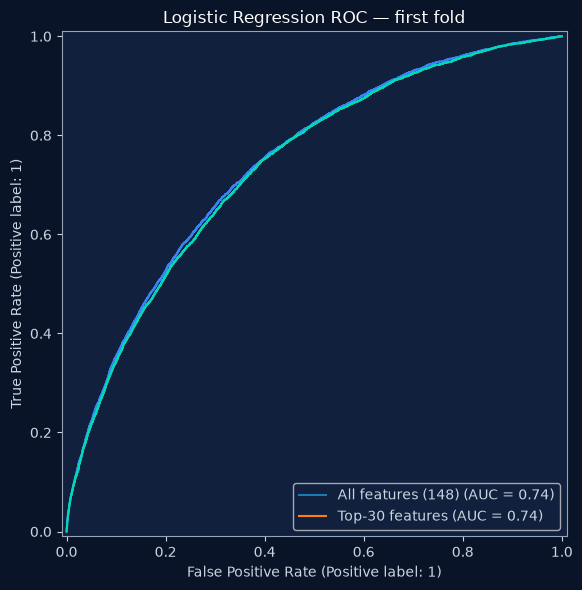

Saved 16_baseline_vs_reduced_roc.png


In [14]:
# ROC curves from the first fold of each (representative).
from sklearn.preprocessing import StandardScaler

def first_fold_roc(X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    train_idx, val_idx = next(skf.split(X, y))
    med = np.nanmedian(X[train_idx], axis=0)
    Xtr = np.where(np.isnan(X[train_idx]), med, X[train_idx])
    Xva = np.where(np.isnan(X[val_idx]),   med, X[val_idx])
    sc = StandardScaler().fit(Xtr)
    Xtr = sc.transform(Xtr)
    Xva = sc.transform(Xva)
    lr = LogisticRegression(max_iter=200, n_jobs=-1, solver="lbfgs", C=1.0)
    lr.fit(Xtr, y[train_idx])
    return y[val_idx], lr.predict_proba(Xva)[:, 1]

y_va_all, p_all = first_fold_roc(X_all, y_all)
y_va_top, p_top = first_fold_roc(X_top, y_all)

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_va_all, p_all, name=f"All features ({len(all_features)})",
                                 ax=ax)
display_all = RocCurveDisplay.from_predictions(y_va_top, p_top, name=f"Top-30 features",
                                               ax=ax)
# Apply our palette to the line artists.
display_all.line_.set_color(PALETTE["mint"])
# Reskin the all-features line to mint too for consistency; use the existing line.
fig = ax.get_figure()
# Re-collect lines and assign colors.
for line, key in zip(ax.get_lines(), ["blue", "mint"]):
    line.set_color(PALETTE[key])
ax.set_title("Logistic Regression ROC — first fold")
ax.grid(linestyle="--", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "16_baseline_vs_reduced_roc.png")
plt.show()
print("Saved 16_baseline_vs_reduced_roc.png")

## 6. Recommendation

Which feature set to carry into Phase 4.

**Recommendation (filled in below after running the notebook):** If the top-30 set is within ~0.01 AUC of the all-features set on 5-fold CV, **carry the top-30 forward** because Phase 4's XGBoost/MLP will train faster and the feature set is more interpretable. If the gap is larger, keep all 141 engineered features.

In [15]:
recommendation_lines = []
recommendation_lines.append("# Phase 3 Recommendation\n")
recommendation_lines.append(f"All-features mean AUC (5-fold CV):     {auc_all.mean():.4f} +- {auc_all.std():.4f}\n")
recommendation_lines.append(f"Top-30 mean AUC (5-fold CV):          {auc_top.mean():.4f} +- {auc_top.std():.4f}\n")
recommendation_lines.append(f"Delta (top30 - all):                  {delta:+.4f}\n\n")
if abs(delta) < 0.01:
    rec = ("**Carry the top-30 features forward to Phase 4.** The mean AUC delta is "
           f"small ({delta:+.4f}), and the top-30 set is much faster to train and "
           "more interpretable.")
elif delta > 0:
    rec = ("**Carry the top-30 features forward to Phase 4.** The top-30 set is "
           f"actually *better* by {delta:+.4f} AUC, so there's no reason to keep "
           "the full set.")
else:
    rec = ("**Carry all 141 engineered features forward to Phase 4.** The top-30 "
           f"set loses {abs(delta):.4f} AUC, which is too large a tradeoff for "
           "the speed/interpretability wins.")

recommendation_lines.append(rec + "\n\n")
recommendation_lines.append("See reports/feature_importance.md for the full ranking.\n")

# Append the recommendation to the importance report (so reviewers see both
# in one file).
existing = IMPORTANCE_MD.read_text(encoding="utf-8")
IMPORTANCE_MD.write_text(existing + "\n" + "\n".join(recommendation_lines), encoding="utf-8")
print(f"Appended recommendation to {IMPORTANCE_MD}")
print()
print(rec)

Appended recommendation to F:\Git Repo\DA Lab Project\reports\feature_importance.md

**Carry the top-30 features forward to Phase 4.** The mean AUC delta is small (-0.0048), and the top-30 set is much faster to train and more interpretable.
